# Fase 0 — Preparação de Dados: Candidatos à Deputado Federal do nordeste 2026 (TSE)

ETL dos dados de candidados das Eleições 2026, gravando no final um **dataset limpo(gold)** para ser utilizado nas fases 1 a 4.

## Configuração

A base se abranje além de apenas deputados federais do nordeste, portanto iremos criar 3 constantes para filtrar apenas os deputados federais do nordeste.

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = ["AL","BA","CE","MA","PB","PE","PI","RN","SE" ]
ANO_ELEICAO = 2026

## 1) Preparação do ambiente

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

os.makedirs('dados', exist_ok=True)
import os
os.makedirs('images/notebook0', exist_ok=True)


## 2) Obter os dados

1. Baixe os arquivos pelo navegador (Portal de Dados Abertos do TSE):
   - Candidatos: 
   - Bens: 
   - Prestação de Contas: 
2. Salve os arquivos **dentro da pasta **, com esses nomes exatos:
   - 
   - 
   - 
3. Rode as células abaixo — elas conferem se os arquivos estão no lugar certo e descompactam.

In [3]:
ZIP_CAND = f"dados/consulta_cand_{ANO_ELEICAO}.zip"
ZIP_BEM = f"dados/bem_candidato_{ANO_ELEICAO}.zip"
ZIP_PRESTACAO = f"dados/prestacao_de_contas_eleitorais_candidatos_{ANO_ELEICAO}.zip"

def conferir_zip(caminho):
    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f"Não encontrei {caminho}. Baixe o arquivo pelo navegador e salve exatamente nesse caminho "
            "(veja os links na célula de markdown acima)."
        )
    if not zipfile.is_zipfile(caminho):
        raise ValueError(f"{caminho} existe, mas não é um .zip válido — baixe de novo pelo navegador.")
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"OK: {caminho} ({tamanho_mb:.1f} MB)")

def descompactar(nome_arquivo_zip, destino):
    with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)
    print(f"Descompactado em {destino}")

conferir_zip(ZIP_CAND)
conferir_zip(ZIP_BEM)
conferir_zip(ZIP_PRESTACAO)

OK: dados/consulta_cand_2026.zip (3.0 MB)
OK: dados/bem_candidato_2026.zip (3.6 MB)
OK: dados/prestacao_de_contas_eleitorais_candidatos_2026.zip (130.8 MB)


In [4]:
descompactar(ZIP_CAND, './files_cand')
descompactar(ZIP_BEM, './files_bem')

Descompactado em ./files_cand
Descompactado em ./files_bem


## 3) Filtrar candidatos (CARGO + UF)

In [5]:
df = pd.read_csv(f'./files_cand/consulta_cand_{ANO_ELEICAO}_BRASIL.csv', sep=';', encoding='latin-1')

# Rastreabilidade: o próprio TSE grava quando gerou este extrato — assim dá pra saber
# exatamente qual snapshot da base está sendo usado, mesmo que o arquivo mude no futuro.
print(f"Extrato gerado pelo TSE em: {df['DT_GERACAO'].iloc[0]} {df['HH_GERACAO'].iloc[0]}")

print("\nCargos disponíveis:")
print(df.DS_CARGO.value_counts())

dfCargo = df[df['DS_CARGO'] == CARGO].copy()
if UF is not None:
    dfCargo = dfCargo[dfCargo['SG_UF'].isin(UF)].copy()

# uma linha por candidato: fica com o turno mais avançado (2º turno quando existir)
dfCargoFinal = dfCargo.loc[dfCargo.groupby('SQ_CANDIDATO')['NR_TURNO'].idxmax()]

print()
print(f"CARGO={CARGO!r}  UF={UF!r}  ->  {dfCargoFinal.shape[0]} candidatos")
dfCargoFinal[['SQ_CANDIDATO', 'NM_CANDIDATO', 'SG_UF', 'SG_PARTIDO', 'DT_NASCIMENTO']].head()

Extrato gerado pelo TSE em: 23/08/2026 19:30:42

Cargos disponíveis:
DS_CARGO
DEPUTADO ESTADUAL     11191
DEPUTADO FEDERAL       7707
DEPUTADO DISTRITAL      429
2º SUPLENTE             327
1º SUPLENTE             326
SENADOR                 317
VICE-GOVERNADOR         202
GOVERNADOR              199
PRESIDENTE               13
VICE-PRESIDENTE          13
Name: count, dtype: int64

CARGO='DEPUTADO FEDERAL'  UF=['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']  ->  2193 candidatos


,SQ_CANDIDATO,NM_CANDIDATO,SG_UF,SG_PARTIDO,DT_NASCIMENTO
12463,20002532430,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,NOVO,10/11/1991
2153,20002532431,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,NOVO,07/06/1985
4722,20002532432,JOÃO CARLOS LIMA UCHÔA,AL,NOVO,12/02/1965
7324,20002532433,ANA CAROLINA BELTRÃO PEIXOTO,AL,NOVO,21/09/1978
4721,20002532434,JOSÉ ALEX BRANDÃO SILVEIRA,AL,NOVO,03/08/1981


## 4) Patrimônio declarado (bens)

In [6]:
dfBem = pd.read_csv('./files_bem/bem_candidato_%d_BRASIL.csv' % ANO_ELEICAO, sep=';', encoding='latin-1')
dfBem['VR_BEM_CANDIDATO'] = dfBem['VR_BEM_CANDIDATO'].str.replace(',', '.').astype(float)

def categorize_assets(asset):
    a = asset.lower()
    if 'veículo' in a or 'moto' in a or 'aeronave' in a or 'embarcação' in a:
        return 'BENS MÓVEIS'
    elif 'casa' in a or 'terreno' in a or 'apartamento' in a or 'prédio' in a or 'loja' in a or 'terra nua' in a:
        return 'BENS IMÓVEIS'
    elif 'poupança' in a or 'renda fixa' in a or 'cdb' in a or 'rdb' in a:
        return 'INVESTIMENTOS RENDA FIXA'
    elif 'ações' in a or 'fundo' in a or 'investimento' in a or 'mercado' in a:
        return 'INVESTIMENTOS RENDA VARIÁVEL'
    elif 'dinheiro' in a or 'depósito bancário' in a or 'numerário' in a:
        return 'DINHEIRO'
    else:
        return 'OUTROS BENS'

dfBem['Categoria_BEM'] = dfBem['DS_TIPO_BEM_CANDIDATO'].apply(categorize_assets)

dfBem_pivot = dfBem.pivot_table(
    index='SQ_CANDIDATO', columns='Categoria_BEM', values='VR_BEM_CANDIDATO', aggfunc='sum'
)
dfBem_pivot.fillna(0, inplace=True)
dfBem_pivot['Total_Bens'] = dfBem_pivot.sum(axis=1)
dfBem_pivot['Total_Bens_Log'] = np.log1p(dfBem_pivot['Total_Bens'])

dfBem_pivot[['Total_Bens', 'Total_Bens_Log']].describe()

Categoria_BEM,Total_Bens,Total_Bens_Log
count,1.373000e+04,13730.000000
mean,2.496684e+06,12.693722
std,2.771848e+07,2.044055
min,0.000000e+00,0.000000
25%,1.165086e+05,11.665729
50%,4.014611e+05,12.902868
75%,1.130000e+06,13.937729
max,2.075000e+09,21.453227


## 5) Prestação de contas eleitorais (despesas contratadas e pagas)

Extraímos as despesas eleitorais diretamente do zip compactado  para os 9 estados do Nordeste.
- **Despesas Contratadas**: representa os compromissos financeiros e gastos totais contratados pela campanha (foco analítico principal do estudo).
- **Despesas Pagas**: representa a parcela financeira já liquidada/desembolsada.
- Realizamos o mapeamento relacional entre  e  para garantir agregação rigorosa 1:1 por candidato.

In [7]:
z_prestacao = zipfile.ZipFile(ZIP_PRESTACAO)

contratadas_dfs = []
prestador_candidato_maps = []

print("Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...")
for uf in UF:
    fname = f"despesas_contratadas_candidatos_{ANO_ELEICAO}_{uf}.csv"
    with z_prestacao.open(fname) as f:
        df_c = pd.read_csv(f, sep=";", encoding="latin-1",
                           usecols=["SQ_PRESTADOR_CONTAS", "SQ_CANDIDATO", "DS_CARGO", "VR_DESPESA_CONTRATADA"])
        prestador_candidato_maps.append(df_c[["SQ_PRESTADOR_CONTAS", "SQ_CANDIDATO"]].drop_duplicates())
        df_c_fed = df_c[df_c["DS_CARGO"].str.upper() == CARGO].copy()
        contratadas_dfs.append(df_c_fed)

df_contratadas = pd.concat(contratadas_dfs, ignore_index=True)
map_prestador_cand = pd.concat(prestador_candidato_maps, ignore_index=True).drop_duplicates()
df_contratadas["VR_DESPESA_CONTRATADA"] = (
    df_contratadas["VR_DESPESA_CONTRATADA"].astype(str).str.replace(",", ".").astype(float)
)
despesas_contratadas = df_contratadas.groupby("SQ_CANDIDATO")["VR_DESPESA_CONTRATADA"].sum().reset_index()
despesas_contratadas.rename(columns={"VR_DESPESA_CONTRATADA": "Total_Despesas_Contratadas"}, inplace=True)

print("Extraindo e processando despesas pagas do Nordeste...")
pagas_dfs = []
for uf in UF:
    fname = f"despesas_pagas_candidatos_{ANO_ELEICAO}_{uf}.csv"
    with z_prestacao.open(fname) as f:
        df_p = pd.read_csv(f, sep=";", encoding="latin-1",
                           usecols=["SQ_PRESTADOR_CONTAS", "VR_PAGTO_DESPESA"])
        pagas_dfs.append(df_p)

df_pagas = pd.concat(pagas_dfs, ignore_index=True)
df_pagas["VR_PAGTO_DESPESA"] = (
    df_pagas["VR_PAGTO_DESPESA"].astype(str).str.replace(",", ".").astype(float)
)
pagas_prestador = df_pagas.groupby("SQ_PRESTADOR_CONTAS")["VR_PAGTO_DESPESA"].sum().reset_index()
pagas_cand = pagas_prestador.merge(map_prestador_cand, on="SQ_PRESTADOR_CONTAS", how="inner")
despesas_pagas = pagas_cand.groupby("SQ_CANDIDATO")["VR_PAGTO_DESPESA"].sum().reset_index()
despesas_pagas.rename(columns={"VR_PAGTO_DESPESA": "Total_Despesas_Pagas"}, inplace=True)

df_despesas_totais = pd.merge(despesas_contratadas, despesas_pagas, on="SQ_CANDIDATO", how="outer").fillna(0.0)
print(f"Candidatos com movimentação financeira identificada: {df_despesas_totais.shape[0]}")
df_despesas_totais.head()

Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...
Extraindo e processando despesas pagas do Nordeste...
Candidatos com movimentação financeira identificada: 3929


,SQ_CANDIDATO,Total_Despesas_Contratadas,Total_Despesas_Pagas
0,20002532430,15500.00,15500.00
1,20002532431,14099.27,14099.27
2,20002532432,19635.06,19635.06
3,20002532433,51044.66,51043.66
4,20002532434,21932.67,21932.67


## 6) Juntar tudo, calcular idade, escolaridade e limpar

A idade mínima elegível para Deputado Federal é 21 anos.
Preservamos todos os candidatos via , atribuindo  em bens e despesas para quem não declarou movimentação.

In [8]:
IDADE_MINIMA_POR_CARGO = {
    "PRESIDENTE": 35, "VICE-PRESIDENTE": 35,
    "GOVERNADOR": 30, "VICE-GOVERNADOR": 30,
    "SENADOR": 35,
    "DEPUTADO FEDERAL": 21, "DEPUTADO ESTADUAL": 21, "DEPUTADO DISTRITAL": 21,
    "PREFEITO": 21, "VICE-PREFEITO": 21,
    "VEREADOR": 18,
}
idade_minima = IDADE_MINIMA_POR_CARGO.get(CARGO, 18)
print(f"Idade mínima elegível para {CARGO}: {idade_minima} anos")

# 1. Merge com bens
dfCandBem = dfCargoFinal.merge(dfBem_pivot, on="SQ_CANDIDATO", how="left")
dfCandBem["Total_Bens"] = dfCandBem["Total_Bens"].fillna(0)
dfCandBem["Total_Bens_Log"] = dfCandBem["Total_Bens_Log"].fillna(0)

# 2. Merge com despesas eleitorais (LEFT JOIN)
dfCandBem = dfCandBem.merge(df_despesas_totais, on="SQ_CANDIDATO", how="left")
dfCandBem["Total_Despesas_Contratadas"] = dfCandBem["Total_Despesas_Contratadas"].fillna(0.0)
dfCandBem["Total_Despesas_Pagas"] = dfCandBem["Total_Despesas_Pagas"].fillna(0.0)
dfCandBem["Total_Despesas_Contratadas_Log"] = np.log1p(dfCandBem["Total_Despesas_Contratadas"])
dfCandBem["Total_Despesas_Pagas_Log"] = np.log1p(dfCandBem["Total_Despesas_Pagas"])

# 3. Mapeamento intervalar de escolaridade (anos de estudo formal)
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}
dfCandBem["ANOS_ESTUDO"] = dfCandBem["DS_GRAU_INSTRUCAO"].map(ANOS_ESTUDO_POR_GRAU)

# 4. Cálculo da idade na data da eleição
dfCandBem["DT_ELEICAO"] = pd.to_datetime(dfCandBem["DT_ELEICAO"], format="%d/%m/%Y")
dfCandBem["DT_NASCIMENTO"] = pd.to_datetime(dfCandBem["DT_NASCIMENTO"], format="%d/%m/%Y")
dfCandBem["IDADE"] = (dfCandBem["DT_ELEICAO"] - dfCandBem["DT_NASCIMENTO"]).dt.days // 365

# 5. Filtragem por idade válida para o cargo
antes = dfCandBem.shape[0]
dfCandBem = dfCandBem[dfCandBem["IDADE"].between(idade_minima, 100)].copy()
print(f"Candidatos removidos por idade inválida: {antes - dfCandBem.shape[0]}")

print(f"Base consolidada final: {dfCandBem.shape[0]} candidatos x {dfCandBem.shape[1]} colunas")
display(dfCandBem[["NM_CANDIDATO", "SG_UF", "IDADE", "ANOS_ESTUDO", "Total_Bens", "Total_Despesas_Contratadas", "Total_Despesas_Contratadas_Log"]].head())

Idade mínima elegível para DEPUTADO FEDERAL: 21 anos
Candidatos removidos por idade inválida: 4
Base consolidada final: 2189 candidatos x 64 colunas


,NM_CANDIDATO,SG_UF,IDADE,ANOS_ESTUDO,Total_Bens,Total_Despesas_Contratadas,Total_Despesas_Contratadas_Log
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,34,16,0.00,15500.00,9.648660
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,41,16,115000.00,14099.27,9.553949
2,JOÃO CARLOS LIMA UCHÔA,AL,61,16,3768482.01,19635.06,9.885123
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,48,16,630000.00,51044.66,10.840476
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,45,16,1092000.00,21932.67,9.995778


> Não removemos os outliers para que na fase 1 (análise descritiva) possamos vê-los para serem discutidos, e o tratamento de outliers é específico de cada técnica, faremos isso na fase 2 (clusterização).

## 7) Salvar o dataset limpo

Salvamos a base final unificada (candidatos + bens + despesas eleitorais + escolaridade) em  para abastecer as Fases 1 a 4.

In [9]:
nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo_saida = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

dfCandBem.to_csv(arquivo_saida, index=False)
print(f"Dataset salvo em: {arquivo_saida}  ({dfCandBem.shape[0]} candidatos, {dfCandBem.shape[1]} colunas)")

Dataset salvo em: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  (2189 candidatos, 64 colunas)


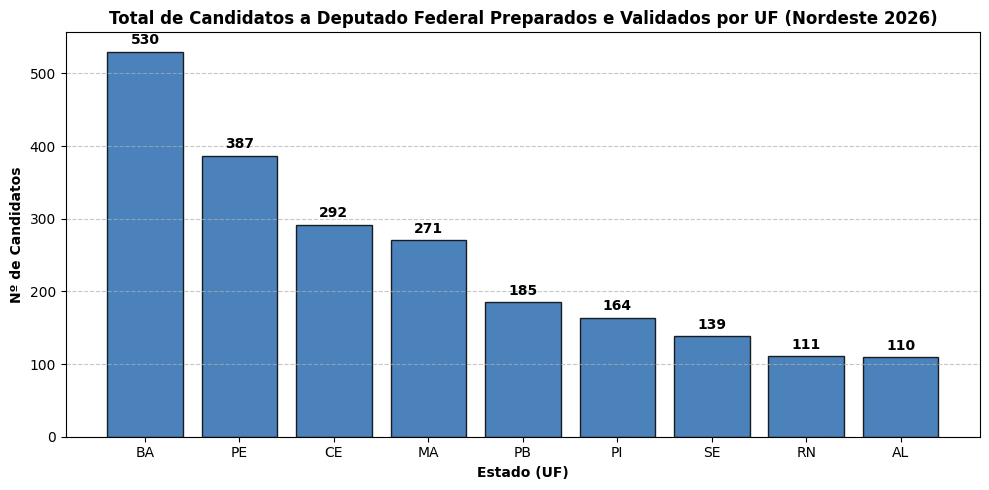

✅ Imagem salva com sucesso: images/notebook0/01_candidatos_por_uf_preparados.png
📦 Arquivo ZIP gerado: images/notebook0.zip


In [10]:
# ── Exportação de Imagens para Apresentação ────────────────────────────────────
import os
import zipfile
import matplotlib.pyplot as plt

os.makedirs('images/notebook0', exist_ok=True)

# 1. Gráfico de síntese: Total de candidatos validados por UF (apenas estados do Nordeste via UF)
fig, ax = plt.subplots(figsize=(10, 5))
cand_por_uf = dfCandBem[dfCandBem['SG_UF'].isin(UF)]['SG_UF'].value_counts().sort_values(ascending=False)
bars = ax.bar(cand_por_uf.index, cand_por_uf.values, color='#2b6cb0', edgecolor='black', alpha=0.85)
ax.bar_label(bars, fmt='%d', padding=3, fontweight='bold')
ax.set_title('Total de Candidatos a Deputado Federal Preparados e Validados por UF (Nordeste 2026)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estado (UF)', fontweight='bold')
ax.set_ylabel('Nº de Candidatos', fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

img_path = 'images/notebook0/01_candidatos_por_uf_preparados.png'
plt.savefig(img_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Imagem salva com sucesso: {img_path}")

# Compactar imagens do notebook 0 em zip para download fácil
zip_path = 'images/notebook0.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk('images/notebook0'):
        for file in files:
            if not file.endswith('.zip'):
                zipf.write(os.path.join(root, file), arcname=file)
print(f"📦 Arquivo ZIP gerado: {zip_path}")
